/tmp/ipykernel_55/1289945575.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_symbol, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Data Downloaded Successfully ✅
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400505  72.460769  71.156667  71.409770  135480400
2020-01-03  71.696625  72.455943  71.472447  71.629130  146322800
2020-01-06  72.267929  72.306499  70.568503  70.819201  118387200
2020-01-07  71.928055  72.533095  71.708695  72.277578  108872000
2020-01-08  73.085114  73.386431  71.631559  71.631559  132079200

Model Performance:
MAE: 1.65
RMSE: 2.22


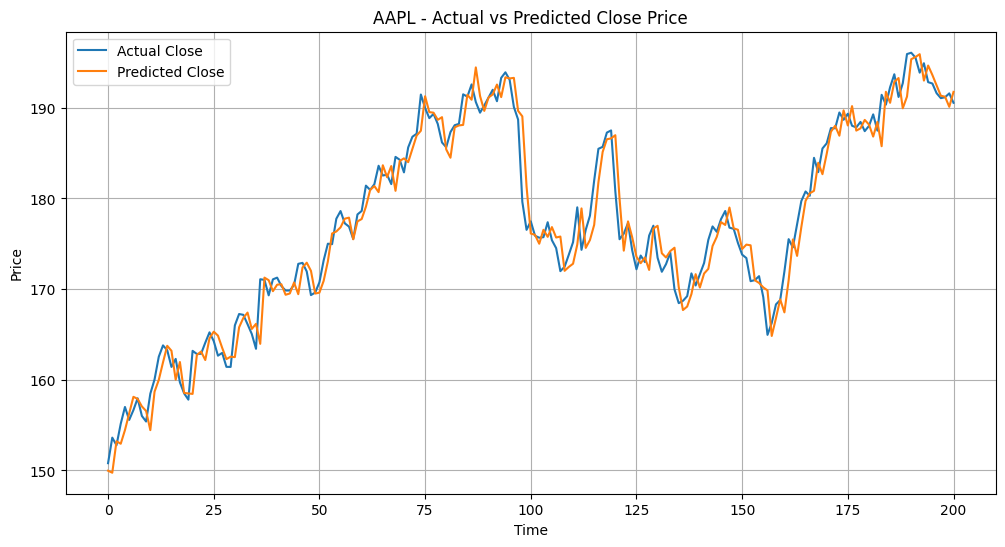

In [1]:
# ============================================
# 📈 Stock Price Prediction (Kaggle Version)
# ============================================

# Install required libraries (if needed)
!pip install -q yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------
# 1️⃣ Download Stock Data
# -----------------------------
stock_symbol = "AAPL"   # Change to "TSLA" for Tesla

data = yf.download(stock_symbol, start="2020-01-01", end="2024-01-01")

print("Data Downloaded Successfully ✅")
print(data.head())

# -----------------------------
# 2️⃣ Create Target (Next Day Close)
# -----------------------------
data["Next_Close"] = data["Close"].shift(-1)

# Remove last row (NaN target)
data = data.dropna()

# Features & Target
X = data[["Open", "High", "Low", "Volume"]]
y = data["Next_Close"]

# -----------------------------
# 3️⃣ Time-Series Train/Test Split
# -----------------------------
split_index = int(len(data) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

# -----------------------------
# 4️⃣ Train Linear Regression
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# -----------------------------
# 5️⃣ Model Evaluation
# -----------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nModel Performance:")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

# -----------------------------
# 6️⃣ Plot Actual vs Predicted
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual Close")
plt.plot(y_pred, label="Predicted Close")
plt.title(f"{stock_symbol} - Actual vs Predicted Close Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()